# TPC-AgentCF Colab Quickstart

This notebook avoids DeepSeek/OpenAI calls. It downloads and uses a small free local model from Hugging Face: `google/flan-t5-small`.

It now prepares two configs:
- `primary`: the paper-style default threshold (`conflict_threshold = 0.35`)
- `sensitivity`: a clearly labeled calibration run (`conflict_threshold = 0.15`) used only if the primary run produces no conflict users


In [1]:
import os
from pathlib import Path

REPO_URL = os.environ.get("TPC_AGENTCF_REPO_URL", "https://github.com/elom354/tpc-agentcf.git")
REPO_DIR = Path("/content/TPC-AgentCF")

if REPO_DIR.exists():
    print("Repo already present at", REPO_DIR)
else:
    !git clone "$REPO_URL" "$REPO_DIR"

%cd /content/TPC-AgentCF
print("Repo ready at", REPO_DIR)

Cloning into '/content/TPC-AgentCF'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 112 (delta 28), reused 108 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 63.65 KiB | 1.04 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/TPC-AgentCF
Repo ready at /content/TPC-AgentCF


In [1]:
%cd /content/TPC-AgentCF
!python -m pip install --upgrade pip
!pip install "numpy<2" pytest transformers sentencepiece
!pip install -r requirements.txt

/content/TPC-AgentCF
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyterlab-4.5.7-py3-none-any.whl.metadata (16 kB)
  Using cached jedi-0.20.0-py2.py3-none-any.whl.metadata (23 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 17.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 55.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [jupyter]


In [2]:
import copy
import os
import yaml
from pathlib import Path

# Hard-disable remote paid endpoints for the notebook run.
for key in ['OPENAI_API_KEY', 'OPENAI_BASE_URL', 'OPENAI_MODEL']:
    os.environ.pop(key, None)

default_config_path = Path('config/default.yaml')
primary_config_path = Path('config/colab_localhf_primary.yaml')
sensitivity_config_path = Path('config/colab_localhf_sensitivity.yaml')

with default_config_path.open('r', encoding='utf-8') as handle:
    base_config = yaml.safe_load(handle)

def build_config(conflict_threshold: float, escalation_threshold: float) -> dict:
    config = copy.deepcopy(base_config)
    config['llm']['backend'] = 'local_hf'
    config['llm']['model'] = 'google/flan-t5-small'
    config['llm']['max_tokens'] = 64
    config['data']['dataset'] = 'movielens'
    config['data']['max_users'] = 100
    config['data']['max_items'] = 500
    config['evaluation']['run_ablations'] = True
    config['conflict']['conflict_threshold'] = conflict_threshold
    config['conflict']['escalation_threshold'] = escalation_threshold
    return config

primary_config = build_config(conflict_threshold=0.35, escalation_threshold=0.50)
sensitivity_config = build_config(conflict_threshold=0.15, escalation_threshold=0.20)

with primary_config_path.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(primary_config, handle, sort_keys=False)
with sensitivity_config_path.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(sensitivity_config, handle, sort_keys=False)

print('Wrote', primary_config_path)
print('Wrote', sensitivity_config_path)
print('Primary threshold:', primary_config['conflict']['conflict_threshold'])
print('Sensitivity threshold:', sensitivity_config['conflict']['conflict_threshold'])


Wrote config/colab_localhf_primary.yaml
Wrote config/colab_localhf_sensitivity.yaml
Primary threshold: 0.35
Sensitivity threshold: 0.15


In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = 'google/flan-t5-small'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
print('Downloaded local model:', model_name)
print('Number of parameters:', sum(p.numel() for p in model.parameters()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Downloaded local model: google/flan-t5-small
Number of parameters: 76961152


In [4]:
!python -m pytest -q

..............                                                           [100%]
14 passed in 20.85s


In [5]:
!python scripts/prepare_data.py --config config/colab_localhf_primary.yaml

2026-05-03 04:48:33,359 | INFO | src.data.preprocess | Cross-domain filter kept 610 users.
2026-05-03 04:48:33,491 | INFO | __main__ | Prepared dataset with 96 users, 500 items, 7340 interactions, 96 cross-domain users.


In [6]:
!python scripts/run_baselines.py --config config/colab_localhf_primary.yaml

2026-05-03 04:48:42,231 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 04:48:42,232 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-03 04:48:42,243 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
2026-05-03 04:48:42,331 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 04:48:42,342 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-03 04:48:42,435 | INFO | httpx | HTTP Requ

In [7]:
!python scripts/run_tpc_agentcf.py --config config/colab_localhf_primary.yaml

2026-05-03 05:05:30,877 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 05:05:30,878 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-03 05:05:30,889 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
2026-05-03 05:05:30,977 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 05:05:30,987 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-03 05:05:31,078 | INFO | httpx | HTTP Requ

In [8]:
!python scripts/run_ablation.py --config config/colab_localhf_primary.yaml

2026-05-03 05:09:52,408 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 05:09:52,419 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
2026-05-03 05:09:52,507 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 05:09:52,518 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-03 05:09:52,610 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/google/flan-t5-small/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-05-03 05:09:52,700 | INFO | httpx | HTTP Requ

In [9]:
!python scripts/make_paper_tables.py --config config/colab_localhf_primary.yaml

# Research Claims - TPC-AgentCF

## Claim 1: Temporal preference conflict is detectable and frequent.
Conflict Detection Rate: 0.00%

## Claim 2: Popularity calibration reduces bias without accuracy loss.
ARP_conflict: 0.0000 vs ARP_no_conflict: 0.5672

## Claim 3: TPC-AgentCF outperforms AgentCF++ on conflict users.
MRR@10 (conflict users) - AgentCF++: 0.5000, TPC-AgentCF: 0.0000
NDCG@10 (conflict users) - AgentCF++: 0.6309, TPC-AgentCF: 0.0000

## Claim 4: Escalation improves ranking in high-conflict cases.
MRR@10_escalated: 0.0000 vs MRR@10_not_escalated: 0.0917
Escalation Trigger Rate: 0.00%

## Claim 5: Evidence-anchored explanations are more faithful.
Mean Faithfulness Score - TPC-AgentCF: 0.9897



In [10]:
import json
import pandas as pd
from pathlib import Path

recs = pd.read_json('outputs/explanations/recommendations.jsonl', lines=True)
scores = recs['conflict_score']
print('Primary run conflict score summary:')
print(scores.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
print('Users above 0.35:', int((scores >= 0.35).sum()))
print('Users above 0.15:', int((scores >= 0.15).sum()))
print('This does not change the primary result. It only tells you whether a sensitivity calibration is worth running.')


Primary run conflict score summary:
count    776.000000
mean       0.106405
std        0.059807
min        0.000000
50%        0.101172
75%        0.142674
90%        0.188279
95%        0.227678
99%        0.246161
max        0.322111
Name: conflict_score, dtype: float64
Users above 0.35: 0
Users above 0.15: 181
This does not change the primary result. It only tells you whether a sensitivity calibration is worth running.


## Optional Sensitivity Run

Run the next cells only if the primary threshold produces no conflict users. This is a calibration check, not the main reported result. Keep the primary and sensitivity outputs separate when interpreting results.


In [11]:
!python scripts/run_tpc_agentcf.py --config config/colab_localhf_sensitivity.yaml
!python scripts/run_ablation.py --config config/colab_localhf_sensitivity.yaml
!python scripts/make_paper_tables.py --config config/colab_localhf_sensitivity.yaml

2026-05-03 05:51:51,216 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 05:51:51,227 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
2026-05-03 05:51:51,368 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-03 05:51:51,369 | WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-03 05:51:51,380 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-03 05:51:51,471 | INFO | httpx | HTTP Requ

In [12]:
import pandas as pd
all_results = pd.read_csv('outputs/metrics/all_users/tpc_agentcf_results.csv')
conflict_results = pd.read_csv('outputs/metrics/conflict_users/tpc_agentcf_results.csv')
high_conflict_results = pd.read_csv('outputs/metrics/high_conflict_users/tpc_agentcf_results.csv')
display(all_results)
display(conflict_results)
display(high_conflict_results)


,MRR@5,NDCG@5,HitRate@5,Recall@5,MRR@10,NDCG@10,HitRate@10,Recall@10,ARP,HIR,LTC,Novelty,Faithfulness,Conflict Detection Rate,Mean Conflict Score,ARP_conflict,ARP_no_conflict,Escalation Trigger Rate,MRR@10_escalated,MRR@10_not_escalated
0,0.067096,0.086504,0.146907,0.146907,0.083445,0.126834,0.273196,0.273196,0.241125,0.215206,0.746835,2.32442,0.985825,0.28866,0.123852,0.538732,0.524172,0.21134,0.060405,0.089619


,MRR@5,NDCG@5,HitRate@5,Recall@5,MRR@10,NDCG@10,HitRate@10,Recall@10,ARP,HIR,LTC,Novelty,Faithfulness,Conflict Detection Rate,Mean Conflict Score,ARP_conflict,ARP_no_conflict,Escalation Trigger Rate,MRR@10_escalated,MRR@10_not_escalated
0,0.04122,0.057248,0.107143,0.107143,0.056952,0.096729,0.232143,0.232143,0.221614,0.160714,0.784091,2.391682,1.0,1.0,0.212387,0.538732,0.0,0.732143,0.060405,0.047513


,MRR@5,NDCG@5,HitRate@5,Recall@5,MRR@10,NDCG@10,HitRate@10,Recall@10,ARP,HIR,LTC,Novelty,Faithfulness,Conflict Detection Rate,Mean Conflict Score,ARP_conflict,ARP_no_conflict,Escalation Trigger Rate,MRR@10_escalated,MRR@10_not_escalated
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


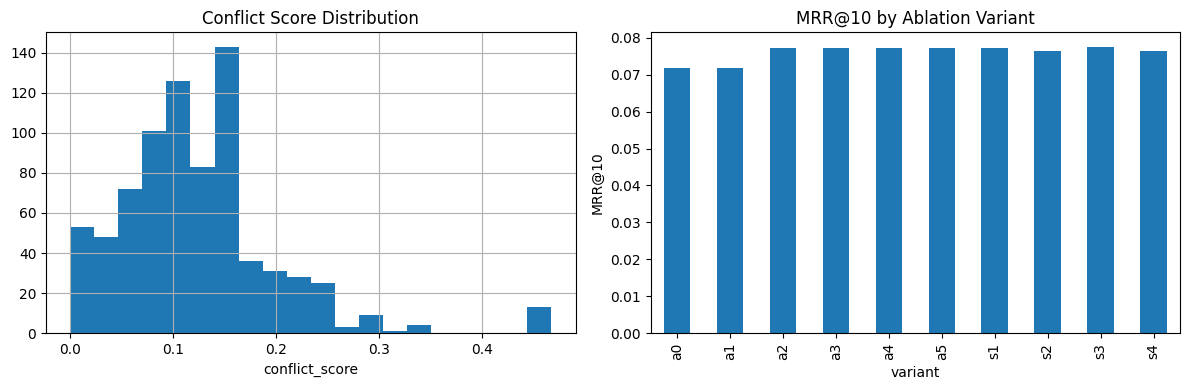

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

recs = pd.read_json('outputs/explanations/recommendations.jsonl', lines=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
recs['conflict_score'].hist(ax=axes[0], bins=20)
axes[0].set_title('Conflict Score Distribution')
axes[0].set_xlabel('conflict_score')

summary = pd.read_csv('outputs/ablations/ablation_results.csv')
pivot = summary[summary['group'] == 'all_users'][['variant', 'MRR@10']].set_index('variant')
pivot.plot(kind='bar', ax=axes[1], legend=False)
axes[1].set_title('MRR@10 by Ablation Variant')
axes[1].set_ylabel('MRR@10')
plt.tight_layout()
plt.show()

In [14]:
from pathlib import Path

for path in [
    'outputs/paper_assets/research_claims.md',
    'outputs/paper_assets/main_table.md',
    'outputs/paper_assets/qualitative_examples.md',
]:
    print('\n' + '=' * 80)
    print(path)
    print('=' * 80)
    print(Path(path).read_text(encoding='utf-8'))


outputs/paper_assets/research_claims.md
# Research Claims - TPC-AgentCF

## Claim 1: Temporal preference conflict is detectable and frequent.
Conflict Detection Rate: 28.87%

## Claim 2: Popularity calibration reduces bias without accuracy loss.
ARP_conflict: 0.5387 vs ARP_no_conflict: 0.5242

## Claim 3: TPC-AgentCF outperforms AgentCF++ on conflict users.
MRR@10 (conflict users) - AgentCF++: 0.5000, TPC-AgentCF: 0.0570
NDCG@10 (conflict users) - AgentCF++: 0.6309, TPC-AgentCF: 0.0967

## Claim 4: Escalation improves ranking in high-conflict cases.
MRR@10_escalated: 0.0604 vs MRR@10_not_escalated: 0.0896
Escalation Trigger Rate: 21.13%

## Claim 5: Evidence-anchored explanations are more faithful.
Mean Faithfulness Score - TPC-AgentCF: 0.9858


outputs/paper_assets/main_table.md
               Model  MRR@10_conflict
AgentCF++-simplified         0.500000
         TPC-AgentCF         0.056952

outputs/paper_assets/qualitative_examples.md
user_id item_id  rank  score domain          exp